In [ ]:

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids
import geopandas as gpd
from shapely.geometry import box
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score
import os
from sklearn.utils import shuffle
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import AgglomerativeClustering

In [6]:
def unsupervised_feature_reduction_kmeans(
    csv_path,
    var_threshold=0.01,
    cluster_distance=0.2,
):
    df = pd.read_csv(csv_path)

    if "fire" in df.columns:
        df = df.drop(columns=["fire"])

    print(f"Initial features: {df.shape[1]}")
 
    selector = VarianceThreshold(threshold=var_threshold)
    selector.fit(df)
    df = df.loc[:, selector.get_support()]
    print(f"After Variance Filter: {df.shape[1]}")
 
    corr_matrix = df.corr().abs()
    distance_matrix = 1 - corr_matrix

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=cluster_distance,
        compute_distances=True,
    )
    clustering.fit(distance_matrix)
    cluster_labels = clustering.labels_

    selected_features = []
    for cluster_id in np.unique(cluster_labels):
        cluster_features = df.columns[cluster_labels == cluster_id]
        if len(cluster_features) == 1:
            selected_features.append(cluster_features[0])
        else:
            cluster_corr = corr_matrix.loc[cluster_features, cluster_features]
            best_feature = cluster_corr.sum().idxmax()
            selected_features.append(best_feature)

    df = df[selected_features]
    print(f"After Clustering: {df.shape[1]}")


    return df


In [ ]:
SILHOUETTE_SAMPLE_RATIO = 0.1  
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

In [9]:

coords = pd.read_csv("Cleaned_dataset/unsupervised/long_lat_attributes.csv")
lat_col = [c for c in coords.columns if 'lat' in c.lower()][0]
lon_col = [c for c in coords.columns if 'lon' in c.lower() or 'long' in c.lower()][0]
 
world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)
countries = world[world['name'].isin(["Algeria", "Tunisia"])]
 
xmin, ymin, xmax, ymax = countries.total_bounds
clipping_rect = box(xmin, 34, xmax, 40) 
countries_clipped = countries.clip(clipping_rect)
 


In [16]:
data_df = pd.read_csv('Cleaned_dataset/unsupervised/data.csv')
long_lat_df = pd.read_csv('Cleaned_dataset/unsupervised/long_lat_attributes.csv')

In [17]:
print(data_df.shape)
print(long_lat_df.shape)
print(data_df.columns)

(851953, 58)
(851953, 2)
Index(['COARSE', 'SAND', 'SILT', 'CLAY', 'BULK', 'REF_BULK', 'ORG_CARBON',
       'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF',
       'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND',
       'elevation', 'winter_prec', 'spring_prec', 'summer_prec', 'autumn_prec',
       'winter_tmax', 'spring_tmax', 'summer_tmax', 'autumn_tmax',
       'winter_tmin', 'spring_tmin', 'summer_tmin', 'autumn_tmin',
       'GRIDCODE_14.0', 'GRIDCODE_16.0', 'GRIDCODE_20.0', 'GRIDCODE_30.0',
       'GRIDCODE_41.0', 'GRIDCODE_50.0', 'GRIDCODE_70.0', 'GRIDCODE_100.0',
       'GRIDCODE_110.0', 'GRIDCODE_120.0', 'GRIDCODE_130.0', 'GRIDCODE_134.0',
       'GRIDCODE_150.0', 'GRIDCODE_151.0', 'GRIDCODE_170.0', 'GRIDCODE_190.0',
       'GRIDCODE_200.0', 'GRIDCODE_201.0', 'GRIDCODE_202.0', 'GRIDCODE_203.0',
       'GRIDCODE_210.0', 'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F',
       'TEXTURE_SOTER_M', 'fire_count'],
      dtype='object')


# RESOLUTION 1KM

In [18]:

df = unsupervised_feature_reduction_kmeans(csv_path="Cleaned_dataset/unsupervised/data.csv")
print(df.shape)
print(df.columns)

Initial features: 58
After Variance Filter: 47
After Clustering: 32
(851953, 32)
Index(['PH_WATER', 'ORG_CARBON', 'CN_RATIO', 'CLAY', 'fire_count', 'elevation',
       'TEXTURE_SOTER_C', 'spring_tmin', 'CEC_EFF', 'GRIDCODE_201.0',
       'GRIDCODE_20.0', 'GRIDCODE_151.0', 'spring_tmax', 'spring_prec',
       'GRIDCODE_130.0', 'ESP', 'TEXTURE_SOTER_M', 'ALUM_SAT', 'COARSE',
       'GRIDCODE_50.0', 'GRIDCODE_200.0', 'autumn_prec', 'SILT', 'summer_prec',
       'GRIDCODE_14.0', 'GRIDCODE_150.0', 'TEXTURE_SOTER_F', 'BULK',
       'CEC_CLAY', 'GRIDCODE_30.0', 'winter_prec', 'GRIDCODE_110.0'],
      dtype='object')


In [22]:
df = unsupervised_feature_reduction_kmeans(csv_path="Cleaned_dataset/unsupervised/data.csv")
print(df.shape)
print(df.columns)

X = df.values

def clara_cost(X, medoids):
    distances = pairwise_distances(X, medoids)
    return np.sum(np.min(distances, axis=1))

def CLARA(X, k, n=5, s=None, random_state=42):
    """
    X : array-like, shape (N, d)
    k : number of clusters
    n : number of samples
    s : sample size (default = 40 + 2k)
    """

    np.random.seed(random_state)
    N = X.shape[0]

    if s is None:
        s = min(N, 40 + 2 * k)

    best_cost = np.inf
    best_medoids = None

    # ---- for i = 1 to n ----
    for i in range(n):

        # S_i ← RandomSample(X, s)
        indices = np.random.choice(N, s, replace=False)
        S_i = X[indices]

        # (A_i, C_i) ← PAM(S_i, k)
        pam = KMedoids(
            n_clusters=k,
            method="pam",
            init="k-medoids++",
            random_state=random_state
        )
        pam.fit(S_i)

        C_i = pam.cluster_centers_

        # Evaluate medoids on full dataset
        cost = clara_cost(X, C_i)

        if cost < best_cost:
            best_cost = cost
            best_medoids = C_i

    # C ← Best(C1, ..., Cn)
    C = best_medoids

    # A ← AssignPointsToNearestMedoid(X, C)
    distances = pairwise_distances(X, C)
    A = np.argmin(distances, axis=1)

    return A, C


Initial features: 58
After Variance Filter: 47
After Clustering: 32
(851953, 32)
Index(['PH_WATER', 'ORG_CARBON', 'CN_RATIO', 'CLAY', 'fire_count', 'elevation',
       'TEXTURE_SOTER_C', 'spring_tmin', 'CEC_EFF', 'GRIDCODE_201.0',
       'GRIDCODE_20.0', 'GRIDCODE_151.0', 'spring_tmax', 'spring_prec',
       'GRIDCODE_130.0', 'ESP', 'TEXTURE_SOTER_M', 'ALUM_SAT', 'COARSE',
       'GRIDCODE_50.0', 'GRIDCODE_200.0', 'autumn_prec', 'SILT', 'summer_prec',
       'GRIDCODE_14.0', 'GRIDCODE_150.0', 'TEXTURE_SOTER_F', 'BULK',
       'CEC_CLAY', 'GRIDCODE_30.0', 'winter_prec', 'GRIDCODE_110.0'],
      dtype='object')


# RECHERCHE MEILLEUR PARAMETRES CLARA
## Nb iteration : 5 - 10
## Nb echantillion : 40* 2k - 80* 2k
## k : 5-16

c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6]
Nombre clusters effectifs: 7


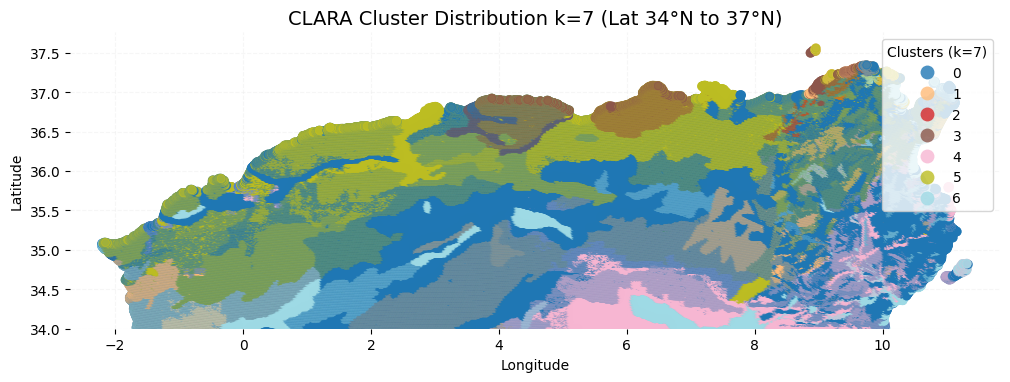

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.1015
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 472955.3819
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1763
  Subset 2 | random_state=43
    Silhouette score: 0.1770
  Subset 3 | random_state=44
    Silhouette score: 0.1758
→ Average Silhouette (K=7): 0.1764


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6, 7]
Nombre clusters effectifs: 8


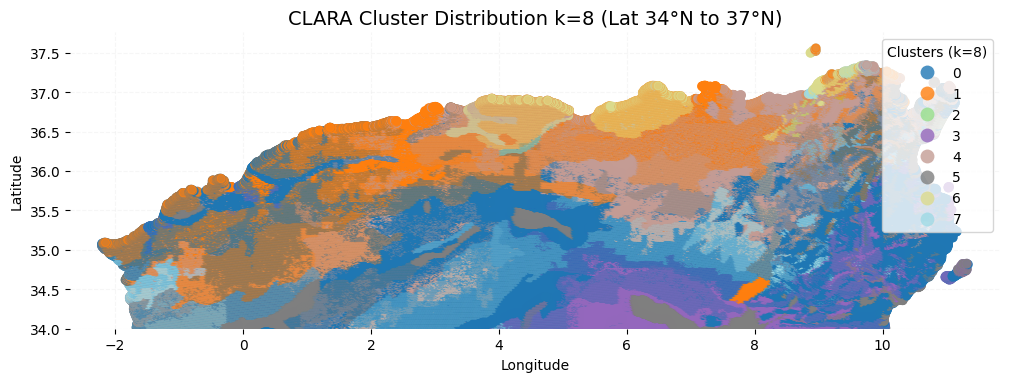

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.3873
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 426285.4623
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1631
  Subset 2 | random_state=43
    Silhouette score: 0.1644
  Subset 3 | random_state=44
    Silhouette score: 0.1640
→ Average Silhouette (K=8): 0.1638


In [23]:
for k in range(7, 9):

    labels_full, medoids = CLARA(X, k=k, n=5, s=40, random_state=BASE_RANDOM_STATE)

    print(f"Labels uniques: {sorted(np.unique(labels_full))}")
    print(f"Nombre clusters effectifs: {len(np.unique(labels_full))}")

    # Combine original coordinates with new CLARA labels
    plot_df = coords.copy()
    plot_df['cluster'] = labels_full

        # Filter Latitude > 34
    df_filtered = plot_df[plot_df[lat_col] > 34].copy()

        # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
            df_filtered, 
            geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
            crs="EPSG:4326"
        )

        # Plot clusters
    fig, ax = plt.subplots(figsize=(12, 12)) 
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)
    gdf.plot(column='cluster', 
                ax=ax, 
                categorical=True, 
                legend=True, 
                cmap='tab20', 
                markersize=35,      
                alpha=0.8,          
                zorder=2,
                legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.title(f"CLARA Cluster Distribution k={k} (Lat 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)
    plt.show()


    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
            rs = BASE_RANDOM_STATE + i
            print(f"  Subset {i+1} | random_state={rs}")

            X_sub, labels_sub = shuffle(
                X, labels_full, random_state=rs
            )

            X_sub = X_sub[:sample_size]
            labels_sub = labels_sub[:sample_size]

            sil = silhouette_score(
                X_sub, labels_sub, metric="euclidean"
            )

            silhouette_scores.append(sil)
            print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6]
Nombre clusters effectifs: 7


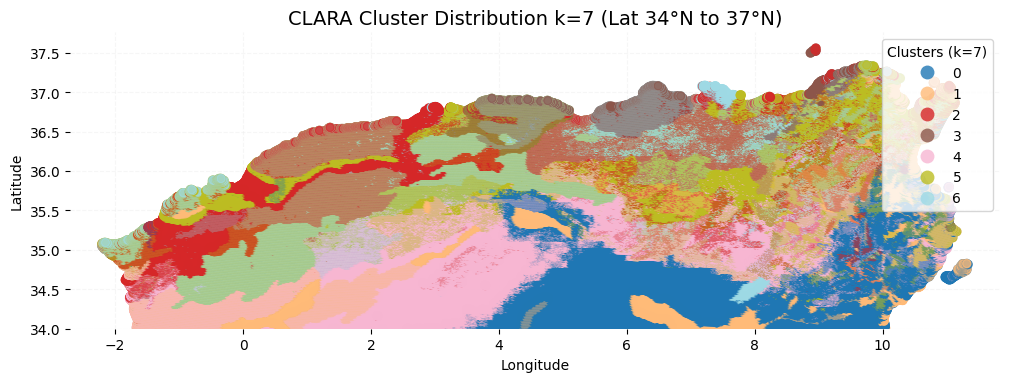

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.8058
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 479104.1554
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1616
  Subset 2 | random_state=43
    Silhouette score: 0.1616
  Subset 3 | random_state=44
    Silhouette score: 0.1618
→ Average Silhouette (K=7): 0.1617


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6, 7]
Nombre clusters effectifs: 8


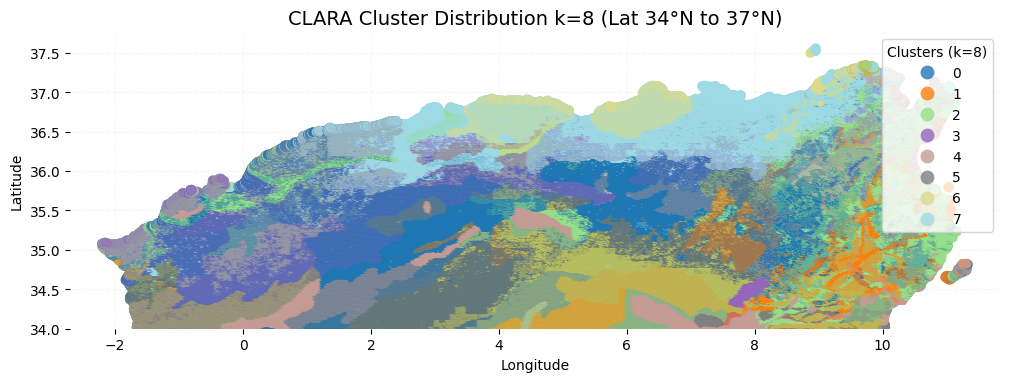

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.5147
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 478598.2375
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1885
  Subset 2 | random_state=43
    Silhouette score: 0.1884
  Subset 3 | random_state=44
    Silhouette score: 0.1874
→ Average Silhouette (K=8): 0.1881


In [24]:
for k in range(7, 9):

    labels_full, medoids = CLARA(X, k=k, n=5, s=80, random_state=BASE_RANDOM_STATE)

    print(f"Labels uniques: {sorted(np.unique(labels_full))}")
    print(f"Nombre clusters effectifs: {len(np.unique(labels_full))}")

    # Combine original coordinates with new CLARA labels
    plot_df = coords.copy()
    plot_df['cluster'] = labels_full

        # Filter Latitude > 34
    df_filtered = plot_df[plot_df[lat_col] > 34].copy()

        # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
            df_filtered, 
            geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
            crs="EPSG:4326"
        )

        # Plot clusters
    fig, ax = plt.subplots(figsize=(12, 12)) 
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)
    gdf.plot(column='cluster', 
                ax=ax, 
                categorical=True, 
                legend=True, 
                cmap='tab20', 
                markersize=35,      
                alpha=0.8,          
                zorder=2,
                legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.title(f"CLARA Cluster Distribution k={k} (Lat 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)
    plt.show()


    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
            rs = BASE_RANDOM_STATE + i
            print(f"  Subset {i+1} | random_state={rs}")

            X_sub, labels_sub = shuffle(
                X, labels_full, random_state=rs
            )

            X_sub = X_sub[:sample_size]
            labels_sub = labels_sub[:sample_size]

            sil = silhouette_score(
                X_sub, labels_sub, metric="euclidean"
            )

            silhouette_scores.append(sil)
            print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6]
Nombre clusters effectifs: 7


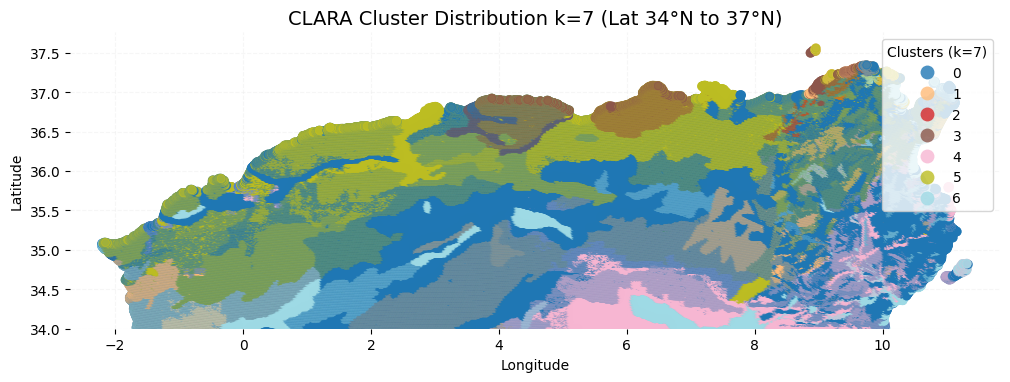

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.1015
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 472955.3819
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1763
  Subset 2 | random_state=43
    Silhouette score: 0.1770
  Subset 3 | random_state=44
    Silhouette score: 0.1758
→ Average Silhouette (K=7): 0.1764


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6, 7]
Nombre clusters effectifs: 8


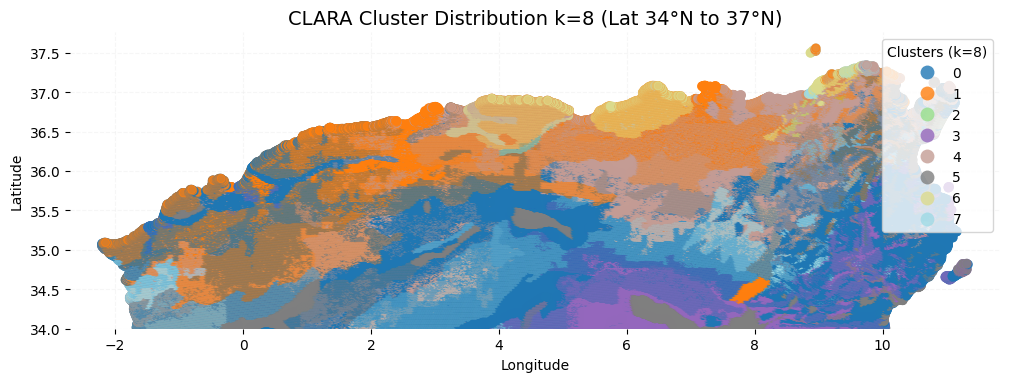

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.3873
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 426285.4623
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1631
  Subset 2 | random_state=43
    Silhouette score: 0.1644
  Subset 3 | random_state=44
    Silhouette score: 0.1640
→ Average Silhouette (K=8): 0.1638


In [25]:
for k in range(7, 9):

    labels_full, medoids = CLARA(X, k=k, n=10, s=40, random_state=BASE_RANDOM_STATE)

    print(f"Labels uniques: {sorted(np.unique(labels_full))}")
    print(f"Nombre clusters effectifs: {len(np.unique(labels_full))}")

    # Combine original coordinates with new CLARA labels
    plot_df = coords.copy()
    plot_df['cluster'] = labels_full

        # Filter Latitude > 34
    df_filtered = plot_df[plot_df[lat_col] > 34].copy()

        # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
            df_filtered, 
            geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
            crs="EPSG:4326"
        )

        # Plot clusters
    fig, ax = plt.subplots(figsize=(12, 12)) 
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)
    gdf.plot(column='cluster', 
                ax=ax, 
                categorical=True, 
                legend=True, 
                cmap='tab20', 
                markersize=35,      
                alpha=0.8,          
                zorder=2,
                legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.title(f"CLARA Cluster Distribution k={k} (Lat 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)
    plt.show()


    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
            rs = BASE_RANDOM_STATE + i
            print(f"  Subset {i+1} | random_state={rs}")

            X_sub, labels_sub = shuffle(
                X, labels_full, random_state=rs
            )

            X_sub = X_sub[:sample_size]
            labels_sub = labels_sub[:sample_size]

            sil = silhouette_score(
                X_sub, labels_sub, metric="euclidean"
            )

            silhouette_scores.append(sil)
            print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6]
Nombre clusters effectifs: 7


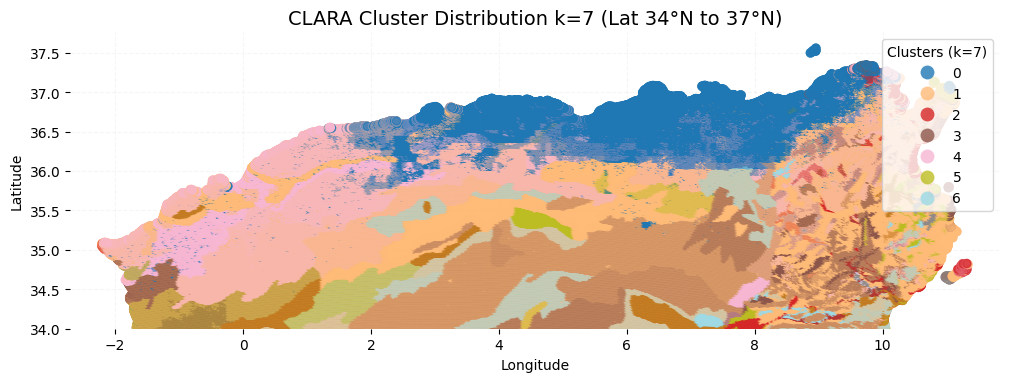

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.2941
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 456046.7430
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.2196
  Subset 2 | random_state=43
    Silhouette score: 0.2209
  Subset 3 | random_state=44
    Silhouette score: 0.2188
→ Average Silhouette (K=7): 0.2198


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6, 7]
Nombre clusters effectifs: 8


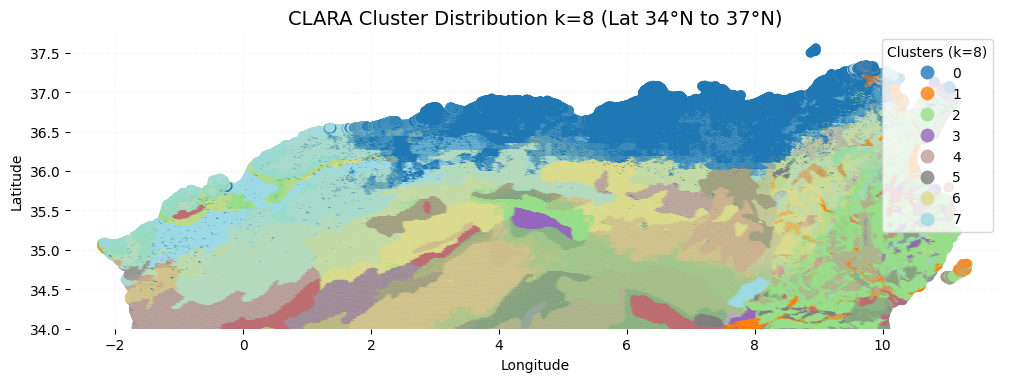

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.3681
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 418029.8883
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.1932
  Subset 2 | random_state=43
    Silhouette score: 0.1924
  Subset 3 | random_state=44
    Silhouette score: 0.1917
→ Average Silhouette (K=8): 0.1924


In [26]:
for k in range(7, 9):

    labels_full, medoids = CLARA(X, k=k, n=10, s=80, random_state=BASE_RANDOM_STATE)

    print(f"Labels uniques: {sorted(np.unique(labels_full))}")
    print(f"Nombre clusters effectifs: {len(np.unique(labels_full))}")

    # Combine original coordinates with new CLARA labels
    plot_df = coords.copy()
    plot_df['cluster'] = labels_full

        # Filter Latitude > 34
    df_filtered = plot_df[plot_df[lat_col] > 34].copy()

        # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
            df_filtered, 
            geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
            crs="EPSG:4326"
        )

        # Plot clusters
    fig, ax = plt.subplots(figsize=(12, 12)) 
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)
    gdf.plot(column='cluster', 
                ax=ax, 
                categorical=True, 
                legend=True, 
                cmap='tab20', 
                markersize=35,      
                alpha=0.8,          
                zorder=2,
                legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.title(f"CLARA Cluster Distribution k={k} (Lat 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)
    plt.show()


    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
            rs = BASE_RANDOM_STATE + i
            print(f"  Subset {i+1} | random_state={rs}")

            X_sub, labels_sub = shuffle(
                X, labels_full, random_state=rs
            )

            X_sub = X_sub[:sample_size]
            labels_sub = labels_sub[:sample_size]

            sil = silhouette_score(
                X_sub, labels_sub, metric="euclidean"
            )

            silhouette_scores.append(sil)
            print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")
